Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Sentences Loaded: 13306


100%|██████████| 1000/1000 [10:26<00:00,  1.60it/s]



Saved: positional_head_scores.csv

BEST POSITIONAL ROLE FOR EACH HEAD
     Layer  Head BestPattern     Score
0        1     1        self  0.264781
1        1     2       prev1  0.092716
2        1     3        self  0.071077
3        1     4       prev1  0.259260
4        1     5       next1  0.074939
..     ...   ...         ...       ...
139     12     8        self  0.507810
140     12     9        self  0.996787
141     12    10        self  0.148416
142     12    11        self  0.980849
143     12    12        self  0.989983

[144 rows x 4 columns]


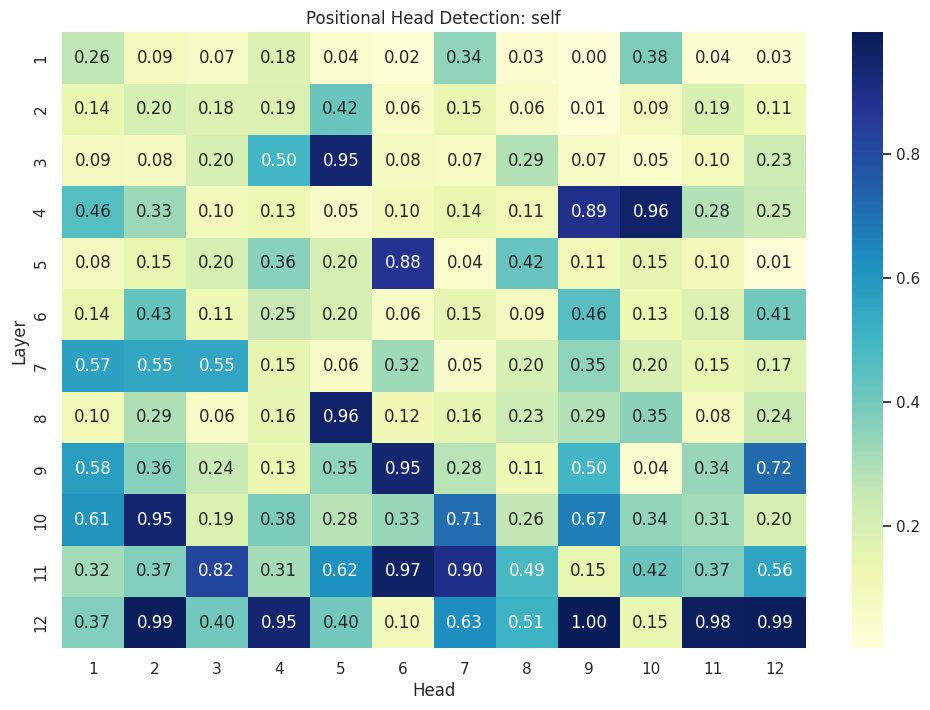

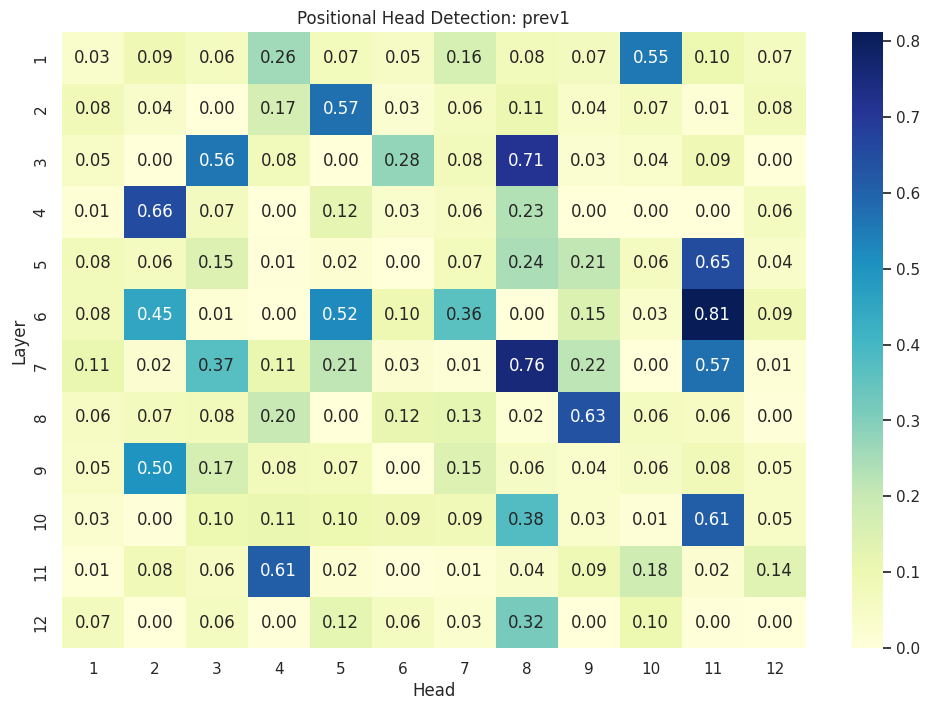

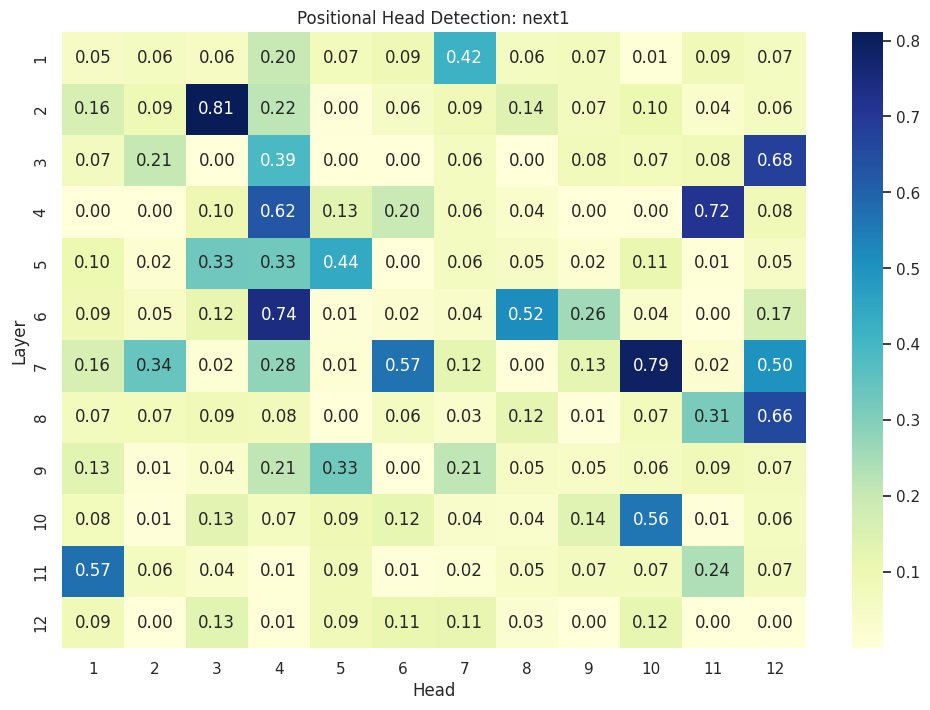

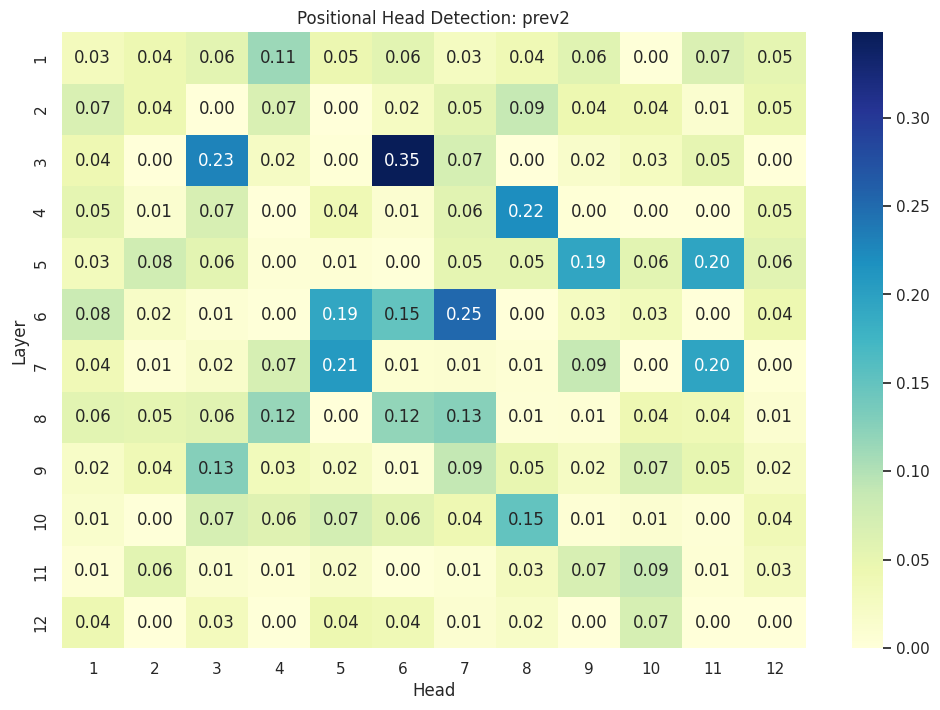

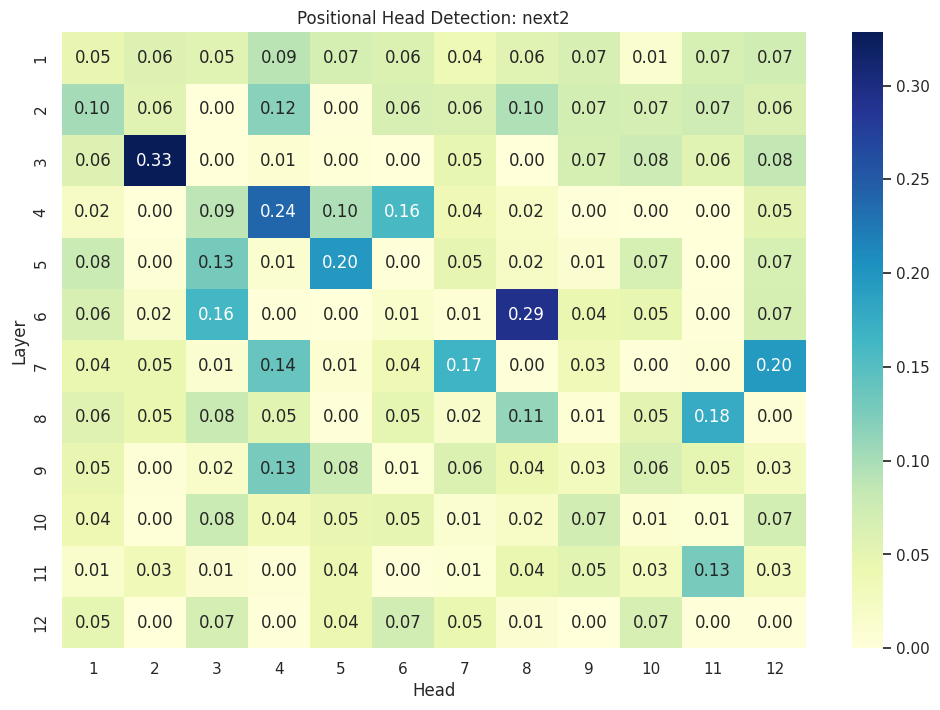

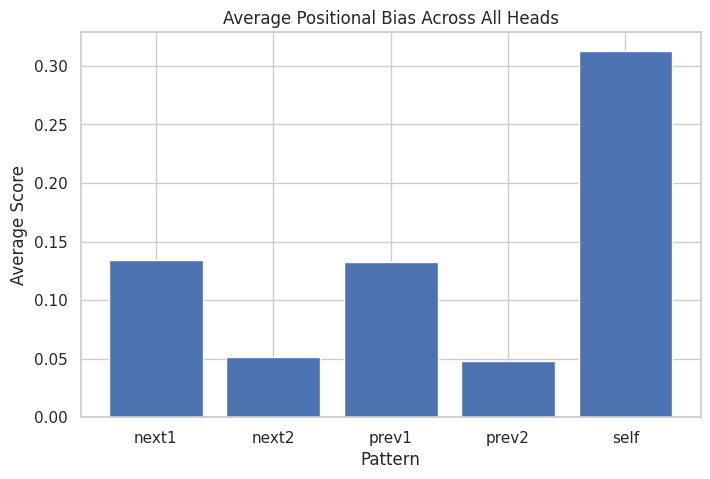


STRONGEST POSITIONAL HEAD OVERALL
Layer            12
Head              9
Pattern        self
Score      0.996787
Name: 704, dtype: object


In [ ]:

# POSITIONAL HEAD DETECTION PIPELINE (BERT + UD DATASET)


!pip -q install transformers torch conllu requests seaborn matplotlib pandas numpy tqdm



import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from tqdm import tqdm
from conllu import parse
from transformers import BertTokenizer, BertModel

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


MODEL_NAME = "bert-base-multilingual-cased"

DATASET_URL = "https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master/hi_hdtb-ud-train.conllu"

NUM_SENTENCES = 1000

MAX_LEN_WORDS = 40

PATTERNS = ["self", "prev1", "next1", "prev2", "next2"]


tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

model = BertModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

model.to(device)
model.eval()


print("Downloading dataset...")

data = requests.get(DATASET_URL).text
sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))


def tokenize_with_alignment(words):

    bert_tokens = ["[CLS]"]
    mapping = {}

    pos = 1

    for i, word in enumerate(words, start=1):

        subs = tokenizer.tokenize(word)

        if len(subs) == 0:
            subs = ["[UNK]"]

        mapping[i] = list(range(pos, pos + len(subs)))

        bert_tokens.extend(subs)
        pos += len(subs)

    bert_tokens.append("[SEP]")

    return bert_tokens, mapping



def get_attention(words):

    sent = " ".join(words)

    inputs = tokenizer(
        sent,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.attentions



def convert_to_word_matrix(token_matrix, mapping, n_words):

    word_matrix = np.zeros((n_words+1, n_words+1))

    for child in range(1, n_words+1):

        child_tokens = mapping[child]

        for parent in range(1, n_words+1):

            parent_tokens = mapping[parent]

            vals = []

            for ct in child_tokens:
                for pt in parent_tokens:
                    vals.append(token_matrix[ct][pt])

            word_matrix[child][parent] = np.mean(vals)

    return word_matrix



def positional_scores(word_matrix, n_words):

    counts = {
        "self": 0,
        "prev1": 0,
        "next1": 0,
        "prev2": 0,
        "next2": 0
    }

    total = 0

    for i in range(1, n_words + 1):

        row = word_matrix[i][1:]   
        pred = np.argmax(row) + 1  

        total += 1

        if pred == i:
            counts["self"] += 1
        if pred == i - 1:
            counts["prev1"] += 1
        if pred == i + 1:
            counts["next1"] += 1
        if pred == i - 2:
            counts["prev2"] += 1
        if pred == i + 2:
            counts["next2"] += 1

    if total == 0:
        return None

    for k in counts:
        counts[k] = counts[k] / total

    return counts



results = []

for idx in tqdm(range(min(NUM_SENTENCES, len(sentences)))):

    try:
        sent = sentences[idx]

        words = []

        for tok in sent:
            if isinstance(tok["id"], int):
                words.append(tok["form"])

        if len(words) < 3:
            continue

        if len(words) > MAX_LEN_WORDS:
            continue

        attentions = get_attention(words)

        _, mapping = tokenize_with_alignment(words)

        n_words = len(words)

        for layer in range(12):
            for head in range(12):

                token_matrix = attentions[layer][0, head].cpu().numpy()

                word_matrix = convert_to_word_matrix(
                    token_matrix,
                    mapping,
                    n_words
                )

                scores = positional_scores(
                    word_matrix,
                    n_words
                )

                if scores is not None:
                    for pattern in PATTERNS:

                        results.append([
                            layer + 1,
                            head + 1,
                            pattern,
                            scores[pattern]
                        ])

    except:
        continue


df = pd.DataFrame(
    results,
    columns=["Layer", "Head", "Pattern", "Score"]
)

avg_df = df.groupby(
    ["Layer", "Head", "Pattern"]
)["Score"].mean().reset_index()

avg_df.to_csv("positional_head_scores.csv", index=False)

print("\nSaved: positional_head_scores.csv")


print("\n===================================")
print("BEST POSITIONAL ROLE FOR EACH HEAD")
print("===================================")

summary_rows = []

for layer in range(1, 13):
    for head in range(1, 13):

        sub = avg_df[
            (avg_df["Layer"] == layer) &
            (avg_df["Head"] == head)
        ]

        if len(sub) == 0:
            continue

        best = sub.sort_values(
            "Score",
            ascending=False
        ).iloc[0]

        summary_rows.append([
            layer,
            head,
            best["Pattern"],
            best["Score"]
        ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Layer", "Head", "BestPattern", "Score"]
)

print(summary_df)

summary_df.to_csv(
    "best_positional_role_per_head.csv",
    index=False
)


for pattern in PATTERNS:

    sub = avg_df[
        avg_df["Pattern"] == pattern
    ]

    pivot = sub.pivot(
        index="Layer",
        columns="Head",
        values="Score"
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu"
    )

    plt.title(f"Positional Head Detection: {pattern}")
    plt.xlabel("Head")
    plt.ylabel("Layer")

    plt.show()


global_avg = avg_df.groupby(
    "Pattern"
)["Score"].mean().reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    global_avg["Pattern"],
    global_avg["Score"]
)

plt.title("Average Positional Bias Across All Heads")
plt.xlabel("Pattern")
plt.ylabel("Average Score")
plt.show()


best = avg_df.sort_values(
    "Score",
    ascending=False
).iloc[0]

print("\n===================================")
print("STRONGEST POSITIONAL HEAD OVERALL")
print("===================================")
print(best)